In [263]:
# Systematic Equity Backtesting Engine
# Author: Yuv Hingarh
# Date: May 2026
# Description: Momentum and mean reversion strategies across 20 S&P 500 stocks

In [264]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import io
import urllib.request 

In [265]:
data = yf.download("SPY", start="2018-01-01", end="2024-12-31")

train_spy_data = data.loc[data.index <= "2022-12-31"]
test_spy_data = data.loc[data.index >= "2023-01-01"]

[*********************100%***********************]  1 of 1 completed


In [266]:
# daily returns
train_spy_data["Returns"] = train_spy_data["Close"].pct_change()
test_spy_data["Returns"] = test_spy_data["Close"].pct_change()

    
# daily cumulative returns
train_spy_data["Cumulative Returns"] = (1 + train_spy_data["Returns"]).cumprod()
test_spy_data["Cumulative Returns"] = (1 + test_spy_data["Returns"]).cumprod()


def get_metrics_spy(data):
    # annual return
    ann_return = data["Returns"].mean() * 252
    
    # annual volatility
    volatility = data["Returns"].std() * np.sqrt(252)
    
    # sharpe ratio: return relative to risk
    sharpe = ann_return / volatility
    
    # sortino ratio: return relative to downside risk
    downside_returns = data["Returns"][data["Returns"] < 0 ]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = ann_return / downside_std
    
    # max drawdown: fall of an asset 
    rolling_max = data["Cumulative Returns"].cummax()
    drawdown = (data["Cumulative Returns"] - rolling_max)/rolling_max
    max_drawdown = drawdown.min()
    
    # win rate
    win_rate = (data["Returns"] > 0).sum() / len(data["Returns"])
    
    
    print("=" * 29)
    print(f"SPY")
    print("=" * 29)
    print(f"Annualized Return:    {ann_return:.2%}")
    print(f"Annualized Volatility:{volatility:.2%}")
    print(f"Sharpe Ratio:         {sharpe:.2f}")
    print(f"Sortino Ratio:        {sortino:.2f}")
    print(f"Max Drawdown:         {max_drawdown:.2%}")
    print(f"Win Rate:             {win_rate:.2%}")

get_metrics_spy(train_spy_data)

SPY
Annualized Return:    11.11%
Annualized Volatility:21.55%
Sharpe Ratio:         0.52
Sortino Ratio:        0.62
Max Drawdown:         -33.72%
Win Rate:             54.25%


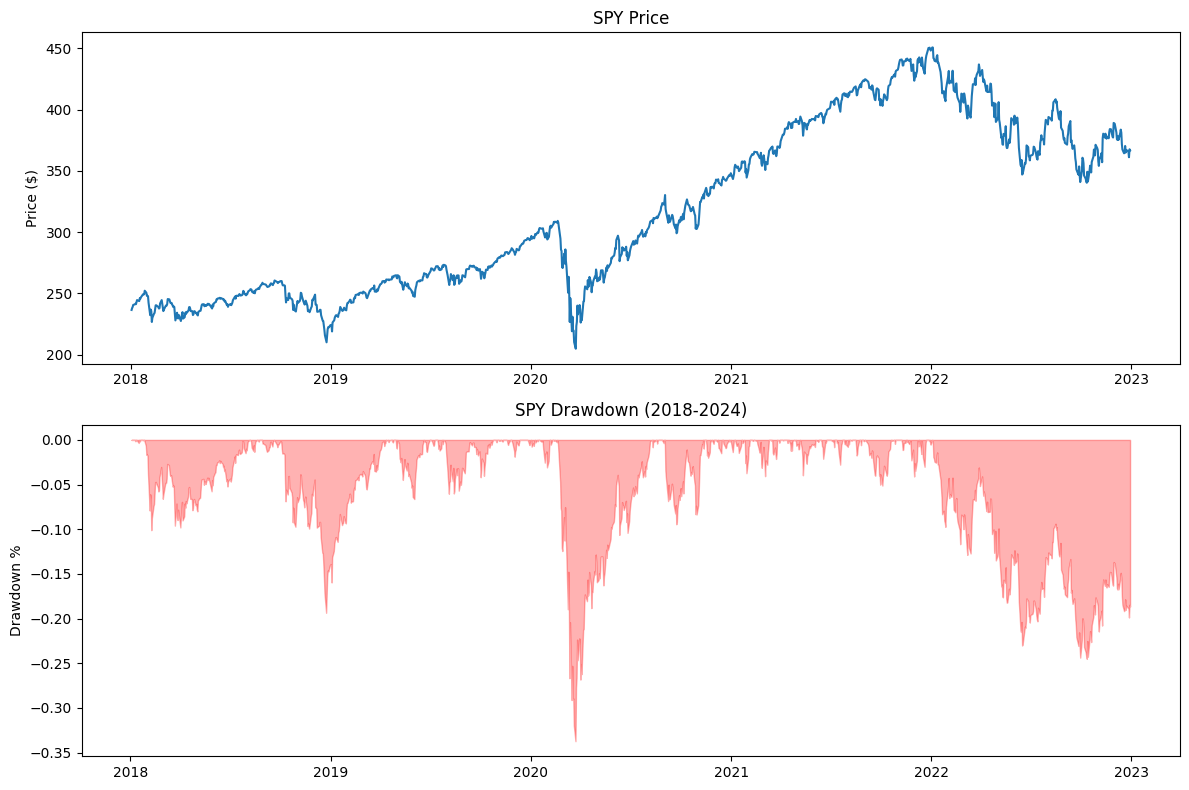

In [267]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(train_spy_data['Close'])
ax1.set_title('SPY Price')
ax1.set_ylabel('Price ($)')

ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
ax2.set_title('SPY Drawdown (2018-2024)')
ax2.set_ylabel('Drawdown %')

plt.tight_layout()
plt.show()

In [268]:
def get_metrics(name, returns):
    ann_return = returns.mean() * 12
    volatility = returns.std() * np.sqrt(12)
    sharpe = (ann_return / volatility)

    downside_returns = returns[ returns < 0 ]
    downside_std = downside_returns.std() * np.sqrt(12)
    sortino = (ann_return / downside_std)

    cum_ret = (1 + returns).cumprod()
    drawdown = (cum_ret - cum_ret.cummax())/cum_ret.cummax()
    max_drawdown = drawdown.min()

    win_rate = (returns > 0).sum() / len(returns)

    print("=" * 29)
    print(f"{name}")
    print("=" * 29)
    print(f"Annualized Return:    {ann_return:.2%}")
    print(f"Annualized Volatility:{volatility:.2%}")
    print(f"Sharpe Ratio:         {sharpe:.2f}")
    print(f"Sortino Ratio:        {sortino:.2f}")
    print(f"Max Drawdown:         {max_drawdown:.2%}")
    print(f"Win Rate:             {win_rate:.2%}")

def plot_compare(name, returns):
    spy_monthly = train_spy_data['Returns'].resample('ME').apply(
    lambda x: (1 + x).prod() - 1)

    spy_monthly_train = spy_monthly.loc[momentum_returns.index]
    spy_cumulative_train = (1 + spy_monthly_train).cumprod()
    
    cumulative = (1 + returns).cumprod()
    drawdown = (cumulative - cumulative.cummax())/cumulative.cummax()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    ax1.plot(cumulative.index, cumulative.values, 
             label= name, color='blue', linewidth=2)
    ax1.plot(spy_cumulative_train.index, spy_cumulative_train.values, 
             label='SPY', color='orange', linewidth=2)
    ax1.set_title(f"{name} vs SPY — Training Period (2019-2022)")
    ax1.set_ylabel('Growth of $1')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.fill_between(drawdown.index, drawdown.values, 0, 
                     color='blue', alpha=0.3, label='Strategy Drawdown')
    ax2.set_title(f"{name} Drawdown")
    ax2.set_ylabel('Drawdown %')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [269]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 
           'NVDA', 'JPM', 'BAC', 'GS', 'MS',
           'JNJ', 'PFE', 'UNH', 'XOM', 'CVX',
           'WMT', 'HD', 'MCD', 'NKE', 'DIS']

ticker_data = yf.download(tickers, start="2018-01-01", end="2024-12-31")["Close"]


# splitting the data. 
# train our data to build strategies
train_data = ticker_data.loc[ticker_data.index <= "2022-12-31"]
# test our strategies on unseen data.
test_data = ticker_data.loc[ticker_data.index >= "2023-01-01"]


train_monthly_prices = train_data.resample("ME").last()
train_monthly_returns = train_monthly_prices.pct_change()

[*********************100%***********************]  20 of 20 completed


Momentum Strategy
Annualized Return:    23.22%
Annualized Volatility:24.09%
Sharpe Ratio:         0.96
Sortino Ratio:        1.96
Max Drawdown:         -20.18%
Win Rate:             54.35%
SPY
Annualized Return:    11.11%
Annualized Volatility:21.55%
Sharpe Ratio:         0.52
Sortino Ratio:        0.62
Max Drawdown:         -33.72%
Win Rate:             54.25%


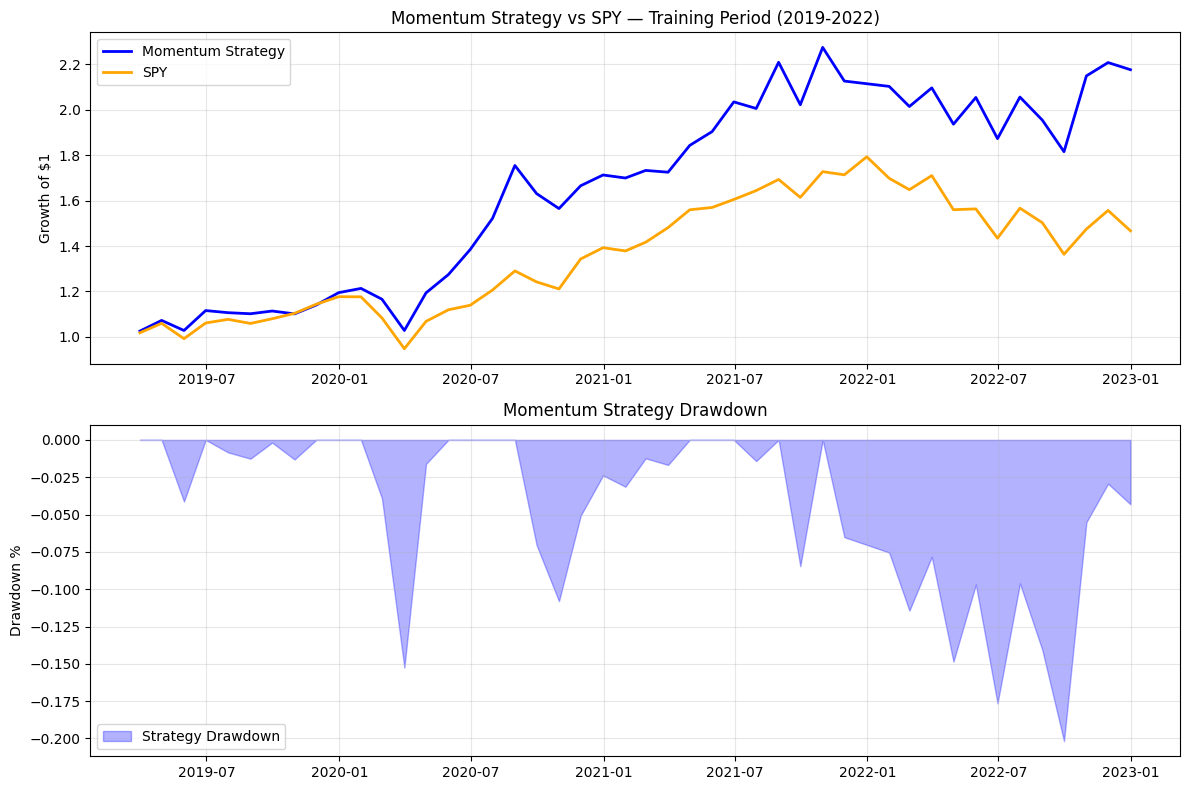

In [270]:
# strategy 1
# momentum: buying assests already trending upward
# investor expectations, herd mentatility

# calculates momentum for a given month for each stock, 12-1
# skips the month before, expects short term reversal
def calculate_momentum(returns, lookback=12, skip=1):
    shifted_returns = returns.shift(skip).rolling(lookback).sum()
    return shifted_returns

momentum_scores = calculate_momentum(train_monthly_returns)

# finding best stock purchase using the strategy
# every month buy 5 stocks, based on previous calculations, equal weight. 
def momentum_strategy(returns, momentum_scores, n_stocks=5):
    momentum_returns = []
    dates = []

    for i in range(len(returns)):
        current_score = momentum_scores.iloc[i]

        if current_score.isna().all():
            continue 
    
        top_stocks = current_score.nlargest(n_stocks).index
    
        if i + 1 < len(returns):
            next_returns = returns.iloc[i + 1][top_stocks]
            strategy_return = next_returns.mean()
            momentum_returns.append(strategy_return)
            dates.append(returns.index[i + 1])

    return pd.Series(momentum_returns, index=dates)

momentum_returns = momentum_strategy(train_monthly_returns, momentum_scores)

get_metrics("Momentum Strategy", momentum_returns)
get_metrics_spy(train_spy_data)

plot_compare("Momentum Strategy", momentum_returns)

Mean Reversion
Annualized Return:    21.03%
Annualized Volatility:27.43%
Sharpe Ratio:         0.77
Sortino Ratio:        1.31
Max Drawdown:         -29.06%
Win Rate:             70.83%
SPY
Annualized Return:    11.11%
Annualized Volatility:21.55%
Sharpe Ratio:         0.52
Sortino Ratio:        0.62
Max Drawdown:         -33.72%
Win Rate:             54.25%


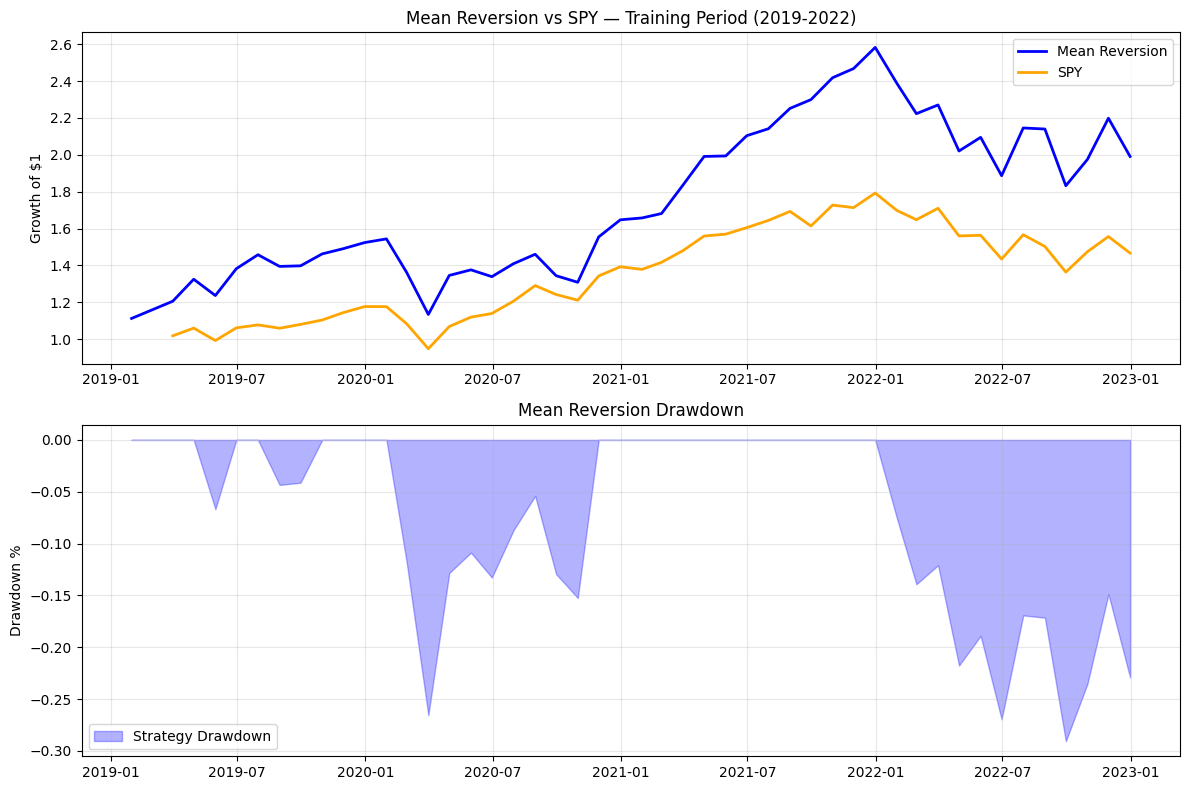

In [271]:
# strategy 2
# mean reversion: buying assests underbought
# value correction, market overreaction

# calculates z score for each stock
# z score tells you how far a stock's current price is from its average price
def cal_z_score(prices):
    rolling_mean = prices.rolling(12).mean()
    rolling_std = prices.rolling(12).std()
    z_scores = (prices - rolling_mean) / rolling_std
    return z_scores

z_scores = cal_z_score(train_monthly_prices)

def mean_reversion(z_scores, returns, n_stocks=5):
    mean_returns = []
    dates = []

    for i in range(len(z_scores)):
        current_score = z_scores.iloc[i]

        if current_score.isna().all():
            continue 
    
        low_stocks = current_score.nsmallest(n_stocks).index
    
        if i + 1 < len(z_scores):
            next_returns = returns.iloc[i + 1][low_stocks]
            strategy_return = next_returns.mean()
            mean_returns.append(strategy_return)
            dates.append(z_scores.index[i + 1])

    return pd.Series(mean_returns, index=dates)

mean_returns = mean_reversion(z_scores, train_monthly_returns)

get_metrics("Mean Reversion", mean_returns)
get_metrics_spy(train_spy_data)

plot_compare("Mean Reversion", mean_returns)


Combined Strategy
Annualized Return:    20.60%
Annualized Volatility:23.83%
Sharpe Ratio:         0.86
Sortino Ratio:        1.58
Max Drawdown:         -21.95%
Win Rate:             65.22%
SPY
Annualized Return:    11.11%
Annualized Volatility:21.55%
Sharpe Ratio:         0.52
Sortino Ratio:        0.62
Max Drawdown:         -33.72%
Win Rate:             54.25%


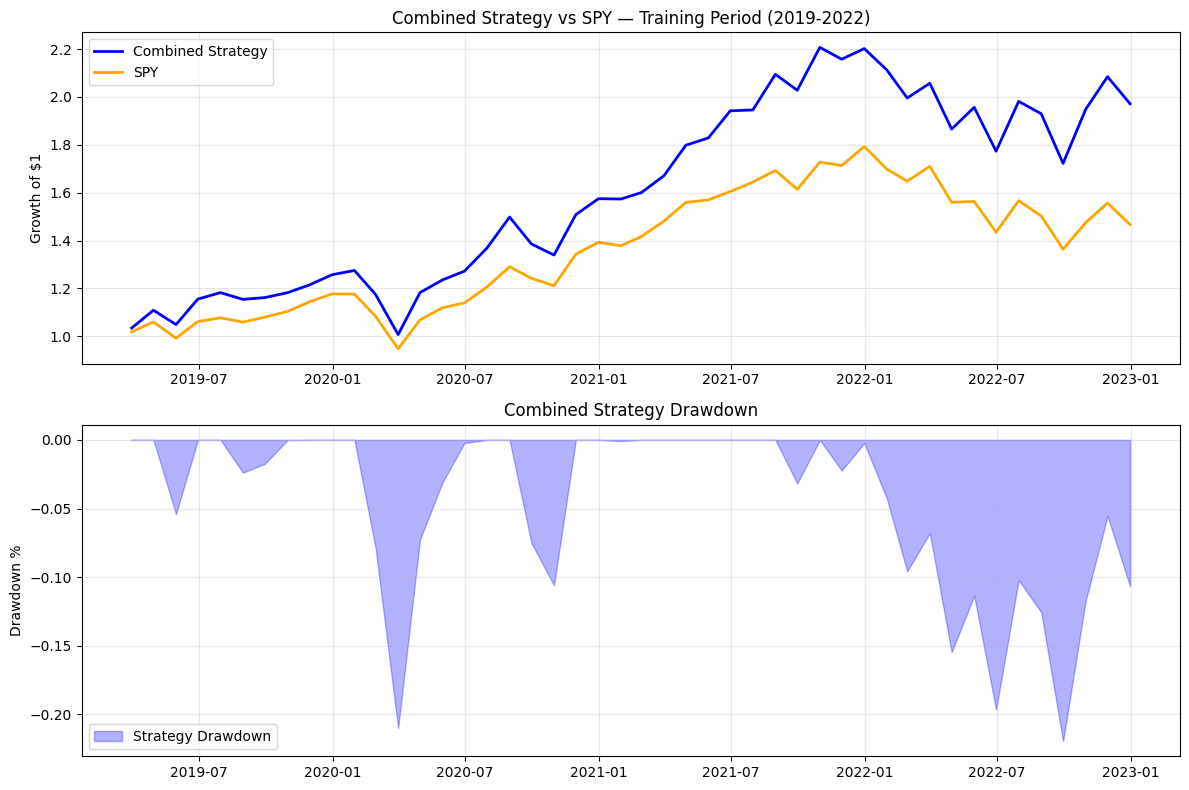

In [272]:
# strategy 3
# combined returns
# using opposing returns to minimise volatility 

def combined_ret(momentum_returns, mean_returns):
    combined = (momentum_returns + mean_returns)/2
    combined = combined.dropna()
    return combined

combined_returns
get_metrics("Combined Strategy", combined_returns)
get_metrics_spy(train_spy_data)

plot_compare("Combined Strategy", combined_returns)


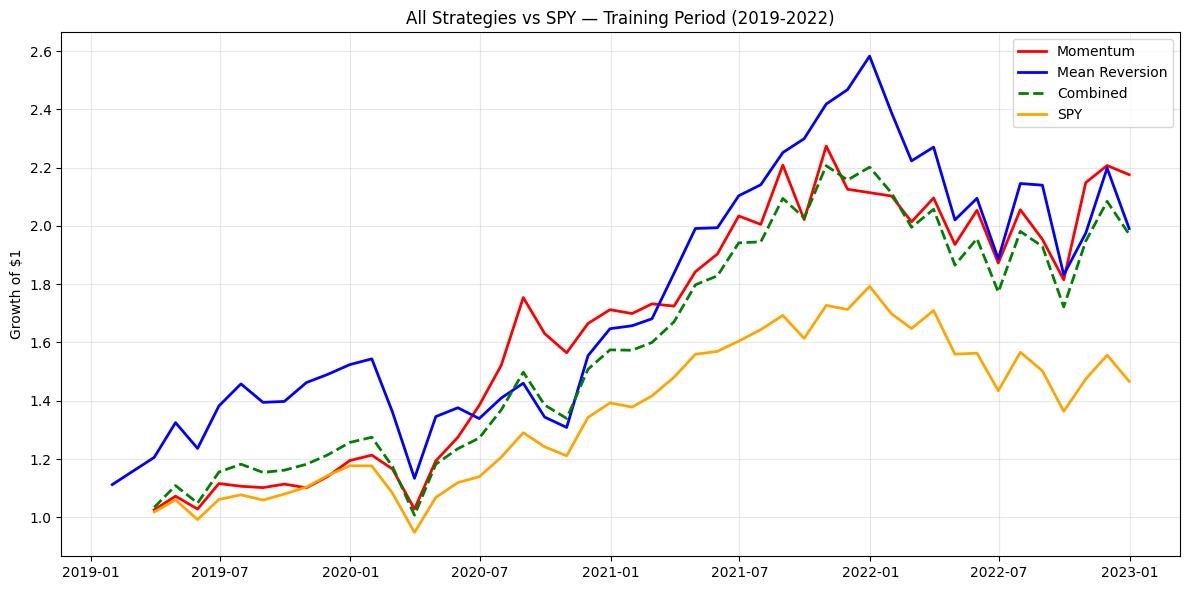

In [273]:
# comparing the three strategies to SPY

momentum_cumulative = (1 + momentum_returns).cumprod()
mean_cumulative = (1 + mean_returns).cumprod()
combined_cumulative = (1 + combined_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(momentum_cumulative.index, momentum_cumulative.values,
         label="Momentum", color='red', linewidth=2)
plt.plot(mean_cumulative.index, mean_cumulative.values,
         label="Mean Reversion", color='blue', linewidth=2)
plt.plot(combined_cumulative.index, combined_cumulative.values,
         label="Combined", color='green', linewidth=2, linestyle='--')
plt.plot(spy_cumulative_train.index, spy_cumulative_train.values,
         label="SPY", color='orange', linewidth=2)
plt.title("All Strategies vs SPY — Training Period (2019-2022)")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Test Momentum
Annualized Return:    40.90%
Annualized Volatility:16.55%
Sharpe Ratio:         2.47
Sortino Ratio:        20.55
Max Drawdown:         -3.68%
Win Rate:             80.00%
Test Mean Reversion
Annualized Return:    18.69%
Annualized Volatility:13.15%
Sharpe Ratio:         1.42
Sortino Ratio:        5.35
Max Drawdown:         -4.16%
Win Rate:             70.00%
Test Combined
Annualized Return:    29.79%
Annualized Volatility:12.62%
Sharpe Ratio:         2.36
Sortino Ratio:        5.58
Max Drawdown:         -3.39%
Win Rate:             80.00%
Test SPY
Annualized Return:    19.79%
Annualized Volatility:10.93%
Sharpe Ratio:         1.81
Sortino Ratio:        3.60
Max Drawdown:         -4.03%
Win Rate:             70.00%


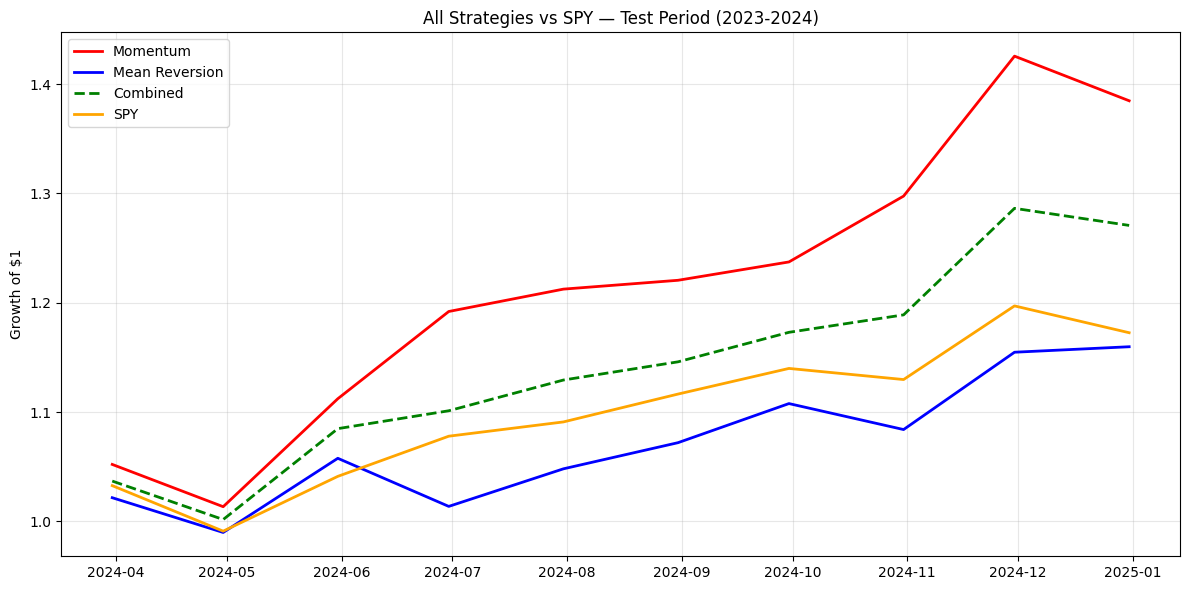

In [274]:
# test data
# note: test period starts March 2024 due to 12-month lookback 
# requirement for momentum signal. Full 2023-2024 test would require incorporating training period history into signal calculation.

test_monthly_prices = test_data.resample('ME').last()
test_monthly_returns = test_monthly_prices.pct_change()

# strategy 1
test_momentum_scores = calculate_momentum(test_monthly_returns)
test_momentum_returns = momentum_strategy(test_monthly_returns, test_momentum_scores)

# strategy 2
test_z_scores = cal_z_score(test_monthly_prices)
test_mean_returns = mean_reversion(test_z_scores, test_monthly_returns)

# spy test
test_spy_monthly = test_spy_data['Returns'].resample('ME').apply(
    lambda x: (1 + x).prod() - 1)

# aligning to common dates
common_idx = test_momentum_returns.index.intersection(test_spy_monthly.index)
test_momentum_returns = test_momentum_returns.loc[common_idx]
test_mean_returns = test_mean_returns.loc[common_idx]
test_spy_monthly = test_spy_monthly.loc[common_idx]

# strategy 3
test_combined_returns = (test_momentum_returns + test_mean_returns) / 2
test_combined_returns = test_combined_returns.dropna()

# data
get_metrics("Test Momentum", test_momentum_returns)
get_metrics("Test Mean Reversion", test_mean_returns)
get_metrics("Test Combined", test_combined_returns)
get_metrics("Test SPY", test_spy_monthly)

# plot
test_momentum_cumulative = (1 + test_momentum_returns).cumprod()
test_mean_cumulative = (1 + test_mean_returns).cumprod()
test_combined_cumulative = (1 + test_combined_returns).cumprod()
test_spy_cumulative = (1 + test_spy_monthly).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(test_momentum_cumulative.index, test_momentum_cumulative.values,
         label="Momentum", color='red', linewidth=2)
plt.plot(test_mean_cumulative.index, test_mean_cumulative.values,
         label="Mean Reversion", color='blue', linewidth=2)
plt.plot(test_combined_cumulative.index, test_combined_cumulative.values,
         label="Combined", color='green', linewidth=2, linestyle='--')
plt.plot(test_spy_cumulative.index, test_spy_cumulative.values,
         label="SPY", color='orange', linewidth=2)
plt.title("All Strategies vs SPY — Test Period (2023-2024)")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()